In [1]:
import pandas as pd  # trabalha com dataframes
import geopandas as gpd  # trabalha com dados geográficos
import matplotlib.pyplot as plt  # trabalha com gráficos
import matplotlib.ticker as mticker  # trabalha com eixos dos gráficos
import numpy as np  # trabalha com cálculos e arrays
import matplotlib.patches as mpatches
from IPython.display import display  # tabelas organizadas
import seaborn as sns

from kneed import KneeLocator #localiza o cotovelo
from sklearn.cluster import KMeans #kmeans
from sklearn.metrics import silhouette_score #silhueta
from sklearn.preprocessing import StandardScaler #normalização

In [2]:
#separando dados
df = pd.read_excel("Base_de_Dados_IDSC-BR_2025.xlsx", sheet_name="Todos os Dados")
geo_df = gpd.read_file(r'C:\Users\Yusan\Downloads\BR_Municipios_2025\BR_Municipios_2025.shp')
geo_df.head()
cols_id   = ['ID', 'Município', 'UF', 'População_2022']
col_nota  = 'Pontuação Indice ODS 2025'
col_ranking  = 'Classificação 2025'

notas = [c for c in df.columns if c.startswith('Goal') and c.endswith('Score')] #17 notas ODS
ods_norm = [c for c in df.columns if c.startswith('Normalizado')] #nota normalizada
ods_bruto = [c for c in df.columns if c.startswith('SDG')]
print("número de colunas")
print("nota:", len(notas))
for i in range(1, 18):
    coluna = f"Goal {i} Score"
    qtd_zeros = (df[coluna] == 0).sum()
    print(f"{coluna}: {qtd_zeros} zeros")

número de colunas
nota: 17
Goal 1 Score: 0 zeros
Goal 2 Score: 0 zeros
Goal 3 Score: 0 zeros
Goal 4 Score: 0 zeros
Goal 5 Score: 0 zeros
Goal 6 Score: 2 zeros
Goal 7 Score: 41 zeros
Goal 8 Score: 0 zeros
Goal 9 Score: 61 zeros
Goal 10 Score: 0 zeros
Goal 11 Score: 0 zeros
Goal 12 Score: 2 zeros
Goal 13 Score: 0 zeros
Goal 14 Score: 3749 zeros
Goal 15 Score: 22 zeros
Goal 16 Score: 1 zeros
Goal 17 Score: 1 zeros


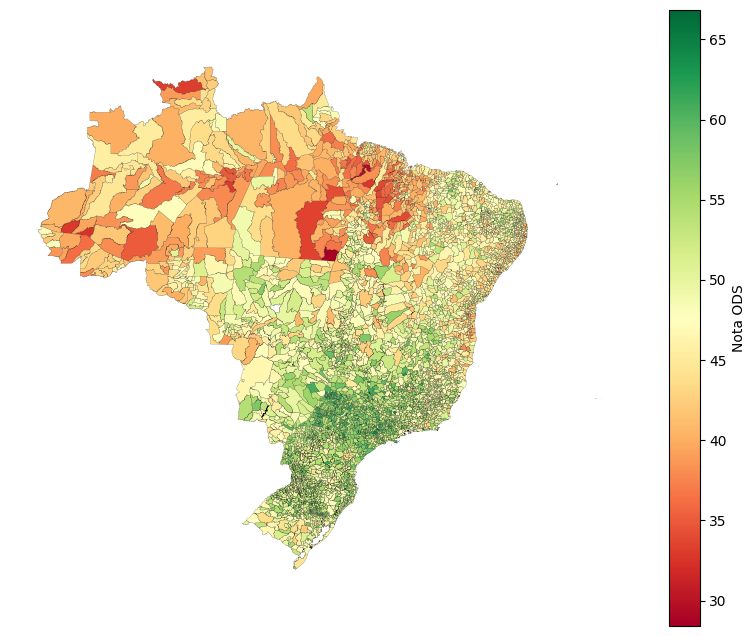

In [3]:
# mapa ODS - nota geral
geo_df['CD_MUN'] = geo_df['CD_MUN'] .astype(int) #transforma o código do município em inteiro
geo_df = geo_df.merge(df, how='left', left_on='CD_MUN', right_on='ID') #a referencia é o df da esquerda (geo_df)
geo_df.head()

fig,ax=plt.subplots(figsize=(10,8)) #fig é a figura, ax é o eixo
#vmin,vmax=0,100 -> desse jeito ficou com pouco contraste
vmin = geo_df['Pontuação Indice ODS 2025'].min()  # menor valor da base
vmax = geo_df['Pontuação Indice ODS 2025'].max()  # maior valor da base
colors = plt.cm.RdYlGn((geo_df['Pontuação Indice ODS 2025']-vmin) / (vmax-vmin)) #deixa tudo entre 0 e 1 e criar escala de cores vermelhas
geo_df.plot(ax=ax, color=colors,edgecolor='black',linewidth=0.1) #desenha o mapa
sm = plt.cm.ScalarMappable(cmap='RdYlGn',norm=plt.Normalize(vmin=vmin,vmax=vmax)) #cria um objeto que explica a barra, 0 início, 100 fim
sm.set_array([]) #scalarmappable exige um array de dados, o array é vazio porque é uma legenda
cbar=plt.colorbar(sm,ax=ax) #cria a barra de cores
cbar.set_label('Nota ODS') #título da barra
ax.axis('off') #oculta os eixos

plt.show()

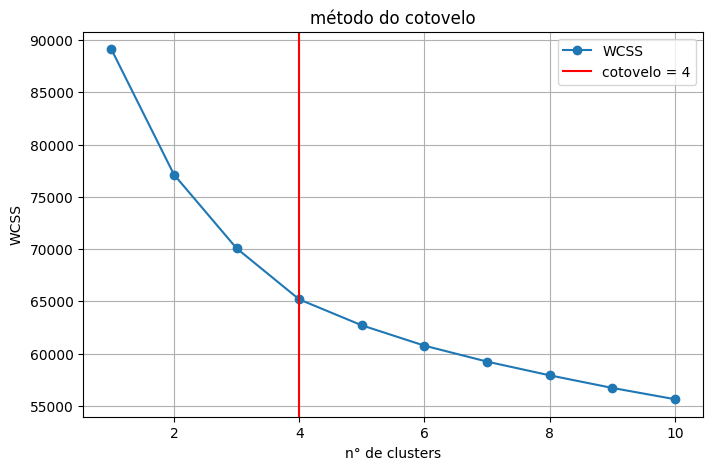

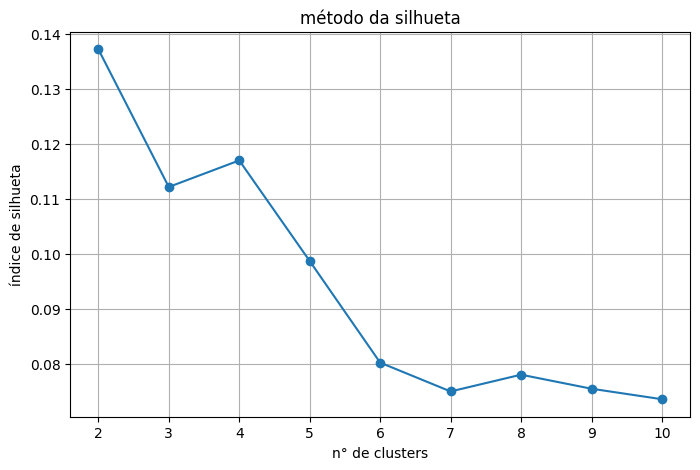

In [4]:
#normalização
X = df[['Goal 1 Score', 'Goal 2 Score', 'Goal 3 Score', 'Goal 4 Score','Goal 5 Score','Goal 6 Score','Goal 7 Score','Goal 8 Score','Goal 9 Score',
'Goal 10 Score','Goal 11 Score','Goal 12 Score','Goal 13 Score','Goal 15 Score','Goal 16 Score','Goal 17 Score']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#método do cotovelo
wcss = []  # vai guardar os valores da inércia (WCSS)
K = range(1, 11)  # testando de 1 a 10 clusters
for k in K:
    modelo = KMeans( #configura os parâmetros da clusterização
        n_clusters=k, #número de clusters sendo testados
        n_init=10, #vai fazer rodar 10 vezes com esse valor de k e escolhe o melhor resultado
        random_state=42)
    modelo.fit(X_scaled) #faz a clusterização em si
    wcss.append(modelo.inertia_) #guarda a inercia encontrada
kneedle = KneeLocator(K,wcss, curve="convex",direction="decreasing") #recebe a lista K e wcss, olha a curva e descobre o cotovelo
plt.figure(figsize=(8,5))
plt.plot(K, wcss, marker='o', label='WCSS') #plot com a bolinha de marcador
plt.axvline(x=kneedle.elbow, color='red',label=f'cotovelo = {kneedle.elbow}') #plota a linha do cotovelo
plt.xlabel("n° de clusters")
plt.ylabel("WCSS")
plt.grid(True) #com grade de fundo
plt.legend()
plt.title("método do cotovelo")
plt.show()

#método da silhueta
silhueta = []
K = range(2, 11)  # testando de 2 a 10 clusters
for k in K:
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)
    grupos = modelo.fit_predict(X_scaled) # executa o kmeans e fala a que cluster cada um se aplica
    silhueta.append(
        silhouette_score(X_scaled, grupos)) #calcula os desvios
plt.figure(figsize=(8,5))
plt.plot(K, silhueta, marker='o')
plt.xlabel("n° de clusters")
plt.ylabel("índice de silhueta")
plt.grid(True)
plt.title("método da silhueta")
plt.show()

C:\Users\Yusan\AppData\Local\Temp\ipykernel_10088\1408314703.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Cluster"] = kmeans.fit_predict(X_scaled) #cria a coluna de cluster
C:\Users\Yusan\AppData\Local\Programs\Python\Python314\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


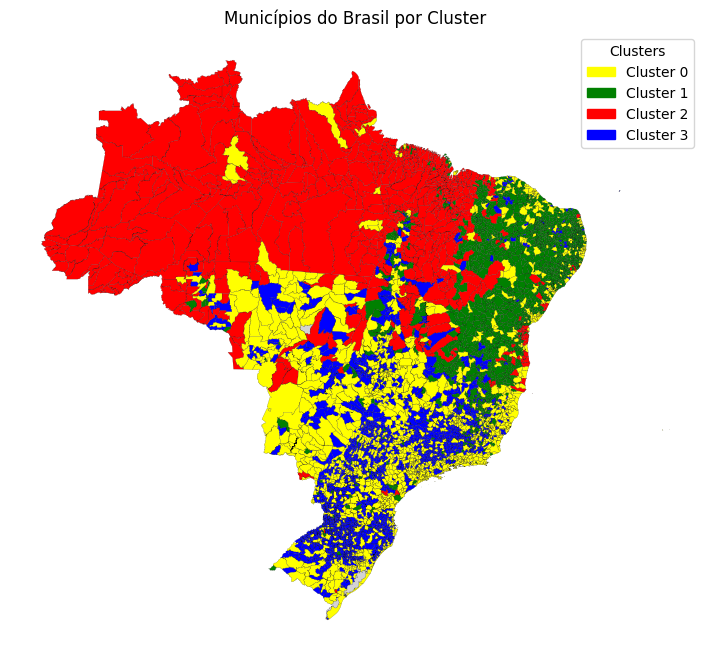

In [5]:
#clusterizacao k-means
k = 4
kmeans = KMeans(n_clusters=k, n_init=20, random_state=42) #n_init 20 pq roda 20 vezes
df["Cluster"] = kmeans.fit_predict(X_scaled) #cria a coluna de cluster

#mapa de municípios coloridos por cluster, com legenda**
geo_df = geo_df.merge(df[['ID', 'Cluster']], how='left', on='ID') #associa a coluna cluster ao geodf (via ID)
cluster_colors = {0: 'yellow', 1: 'green', 2: 'red', 3: 'blue'} #define as cores de cada cluster
geo_df['cor_cluster'] = geo_df['Cluster'].map(cluster_colors) #cria a coluna de cor de cada município a partir do cluster
geo_df['cor_cluster'] = geo_df['cor_cluster'].fillna('lightgrey') #define municípios sem cluster (NaN) com cinza

fig, ax = plt.subplots(figsize=(10, 8))  # fig é a figura, ax é o eixo
geo_df.plot(ax=ax, color=geo_df['cor_cluster'], edgecolor='black', linewidth=0.1)  # configurações do mapa
legenda = []
for cluster in cluster_colors:
    legenda.append( #adiciona o item à lista legenda
        mpatches.Patch(
            color=cluster_colors[cluster],
            label=f'Cluster {cluster}' #cria um "quadrado" com a cor corresposdente do cluster (rótulo)
        )
    ) #cria a legenda
ax.legend(handles=legenda, title="Clusters")
ax.axis('off')  #oculta os eixos
plt.title('Municípios do Brasil por Cluster')  #título do mapa
plt.show()

Nota média do Índice ODS por região:
Regiao
Sudeste         53.625691
Sul             52.606371
Centro-Oeste    49.570672
Nordeste        46.518597
Norte           43.869651
Name: Pontuação Indice ODS 2025, dtype: float64


C:\Users\Yusan\AppData\Local\Temp\ipykernel_10088\124119500.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Regiao'] = df['UF'].map(uf_para_regiao) #cria a coluna "Regiao" a partir da UF


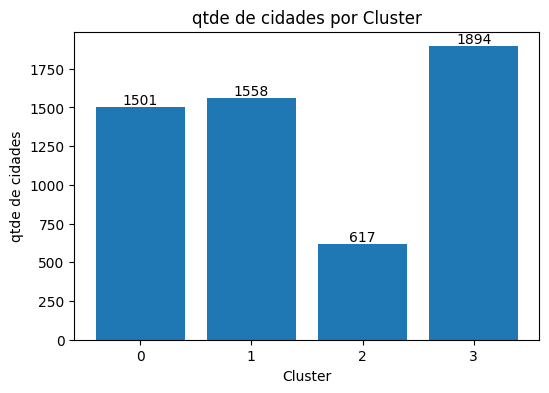

Regiao   Centro-Oeste  Nordeste  Norte  Sudeste  Sul
Cluster                                             
0                 236       248     44      613  360
1                  28      1204     55      240   31
2                  37       280    290        7    3
3                 166        62     61      808  797


In [6]:
uf_para_regiao = {'AC': 'Norte', 'AP': 'Norte', 'AM': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte','AL': 'Nordeste',
                  'BA': 'Nordeste','CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste','PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste',
                  'SE': 'Nordeste','DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste','ES': 'Sudeste',
                  'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste','PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul' } #dicionário de UF para Região

df['Regiao'] = df['UF'].map(uf_para_regiao) #cria a coluna "Regiao" a partir da UF
media_por_regiao = df.groupby('Regiao')[col_nota].mean().sort_values(ascending=False) #calcula a nota média dos ODS por região
print("Nota média do Índice ODS por região:")
print(media_por_regiao)

# quantidade de cidades em cada cluster
qtd_cidades_cluster = df['Cluster'].value_counts().sort_index() #conta quanta vezes aparece o número do cluster

# gráfico de barras da quantidade de cidades por cluster
plt.figure(figsize=(6,4))
plt.bar(qtd_cidades_cluster.index,      # eixo x (clusters)
    qtd_cidades_cluster.values)      # eixo y (quantidade de cidades))
for x, y in zip(qtd_cidades_cluster.index, qtd_cidades_cluster.values):
    plt.text(x, y, str(y), ha='center', va='bottom')
plt.title('qtde de cidades por Cluster')
plt.xlabel('Cluster')
plt.ylabel('qtde de cidades')
plt.xticks(qtd_cidades_cluster.index)  # mostra 0, 1, 2 e 3 no eixo x
plt.show()

# quantidade de cidades por região em cada cluster
qtd_regiao_cluster = pd.crosstab(df['Cluster'], df['Regiao'])
print(qtd_regiao_cluster)

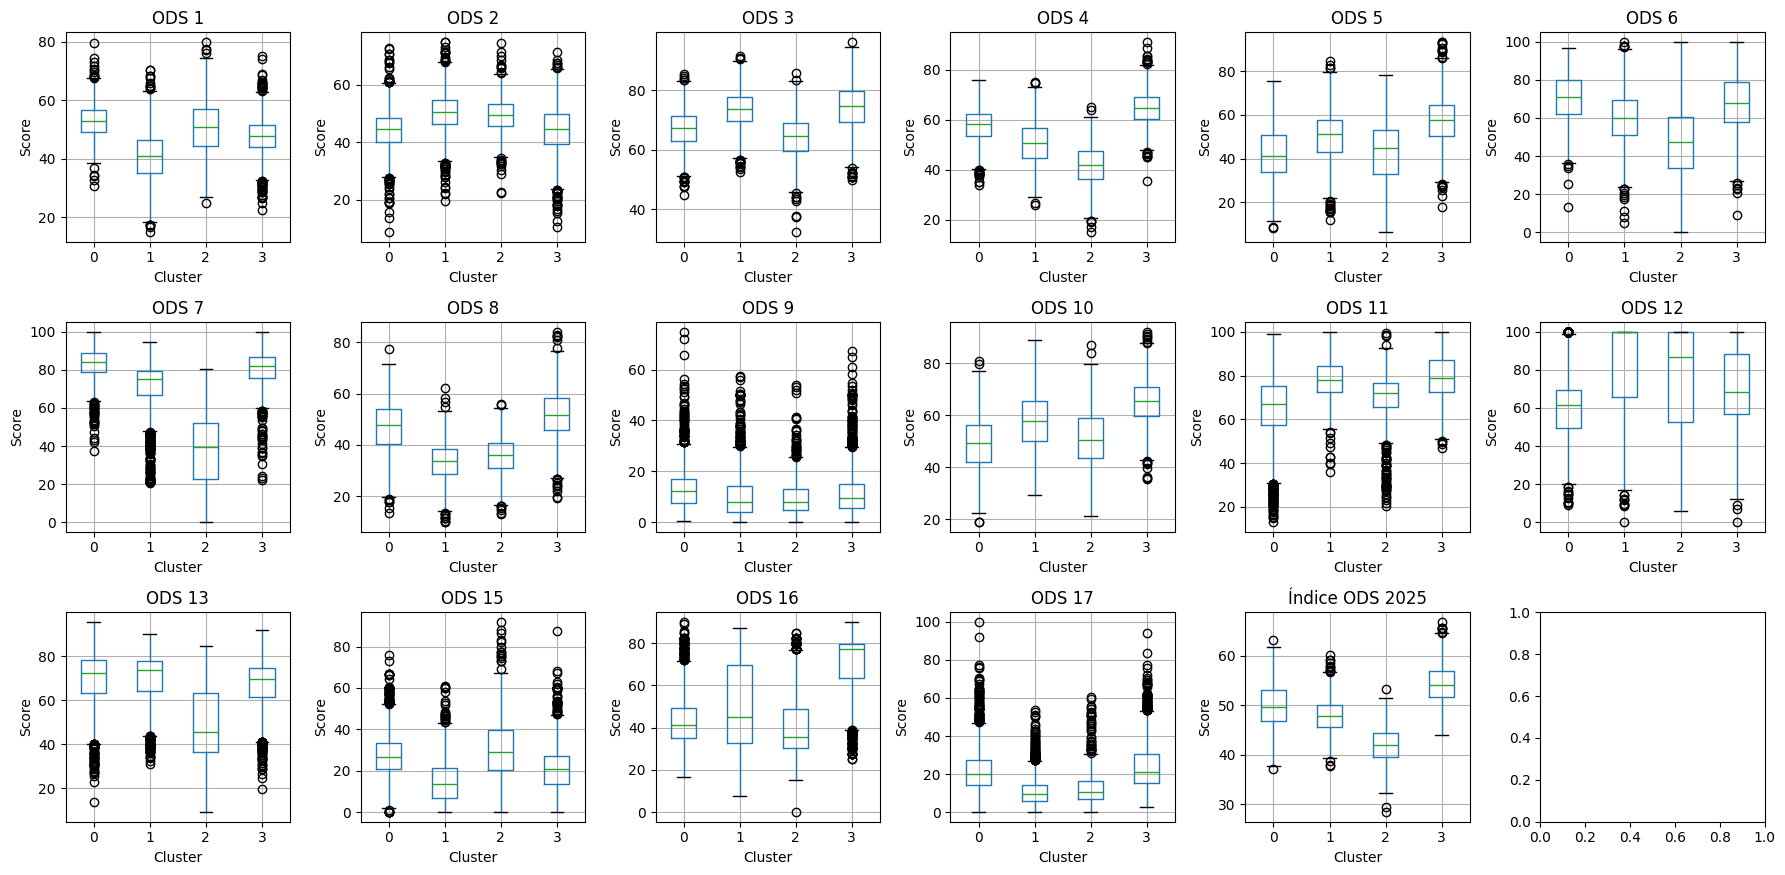

In [7]:
#gráficos boxplot por ODS e cluster
fig, axes = plt.subplots(3, 6, figsize=(18, 9)) #cria a figura e eixos
axes = axes.flatten() #transforma a matriz de eixo em vetor (os 18 eixos)

j = 0  #controla a posição dos gráficos
for i in range(17): #passa pelos 17 ODS
    if i == 13:  # ADICIONADO: pula a ODS 14
        continue
    coluna = f'Goal {i+1} Score' #encontra a coluna 
    df.boxplot( #cria o boxplot
        column=coluna, #coluna ODS usada no boxplot
        by='Cluster', #separa os boxplot por cluster
        ax=axes[j],) # onde fica o grafico
    axes[j].set_title(f'ODS {i+1}') #nome do gráfico
    axes[j].set_xlabel('Cluster') #nome do eixo x
    axes[j].set_ylabel('Score') #nome do eixo y
    j += 1  

# último gráfico com o Índice ODS 2025
df.boxplot(column='Pontuação Indice ODS 2025',by='Cluster',ax=axes[16])
axes[16].set_title('Índice ODS 2025')
axes[16].set_xlabel('Cluster')
axes[16].set_ylabel('Score')
plt.suptitle('')  # remove o título automático
plt.tight_layout()
plt.show()

qtde de municípios no treinamento: 3899
qtde de municípios no teste: 1671
Acurácia do Random Forest: 0.913

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       450
           1       0.90      0.90      0.90       468
           2       0.95      0.86      0.90       185
           3       0.92      0.94      0.93       568

    accuracy                           0.91      1671
   macro avg       0.92      0.90      0.91      1671
weighted avg       0.91      0.91      0.91      1671



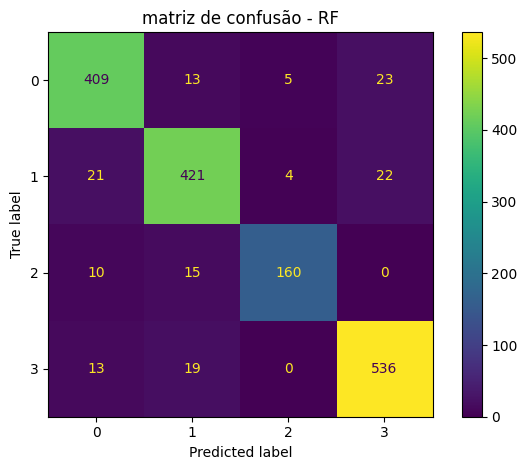

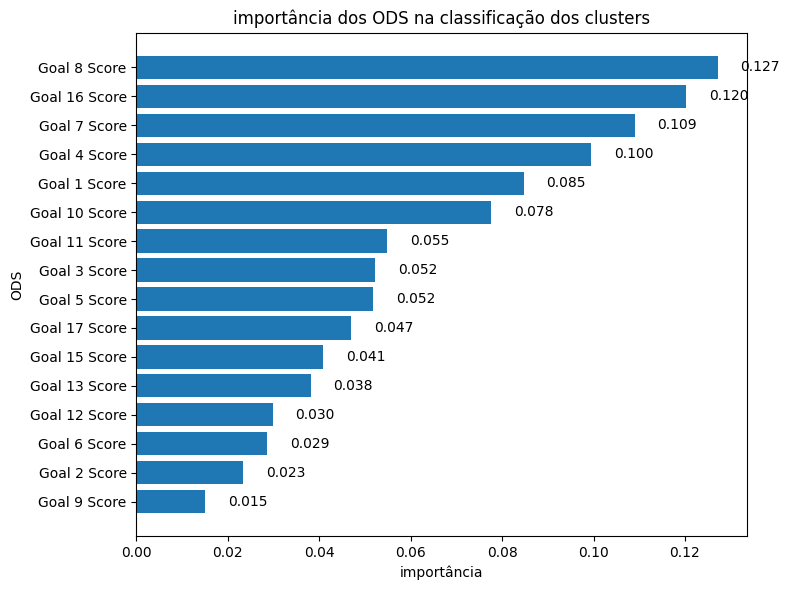

In [14]:
# random forest + feature importance
y = df['Cluster']

#separa treinamento teste (70% treino e 30% teste)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=18,stratify=y) #random_state=18 para divisão reproduzível
#stratify faz com que a proporção de cada cluster no treino seja a mesma proporção de que existe no teste, mantendo a proporção do conjunto original
print("qtde de municípios no treinamento:", len(X_train))
print("qtde de municípios no teste:", len(X_test))

#criar e usar random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=500,random_state=42)   #tenta adivinhar o cluster 500x e escolhe o resultado da maioria  
rf.fit(X_train, y_train) #modelo aprende a relacionar os scores dos ODS com os clusters
y_pred = rf.predict(X_test) #usa o RF já treinado para prever o cluster dos municípios do conjunto teste

#avalia acurácia do modelo
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred) #compara os clusters reais (y_test) com os previstos pelo RF (y_pred)
print(f"Acurácia do Random Forest: {accuracy:.3f}")

# métricas do cluster 
#precision = quantas vezes ele disse que era cluster X e acertou / quanto acertou sobre o total pesquisado
#recall = quantas vezes era cluster X e ele acertou / em cima dos positivos
#f1-score = medida equilibrada entre precision e recall
from sklearn.metrics import classification_report
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred))

# matriz de confusão
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred) #linhas = clusters reais   colunas = clusters previstos
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_) #cria a visualização da matriz
disp.plot()
plt.title('matriz de confusão - RF')
plt.tight_layout()
plt.show()


#feature importance do RF
importancias = pd.DataFrame({'ODS': X.columns, 'Importancia': rf.feature_importances_}) #calcula a importancia de cada variável
importancias = importancias.sort_values('Importancia', ascending=False) #ordena os ODS da maior para a menor importância
importancias_plot = importancias.sort_values('Importancia',ascending=True) #ordena da menor para a maior importância
plt.figure(figsize=(8, 6))
barras = plt.barh(importancias_plot['ODS'],importancias_plot['Importancia']) #cria o gráfico de barras do feature importance
plt.xlabel('importância')
plt.ylabel('ODS')
plt.title('importância dos ODS na classificação dos clusters')
for barra in barras:
    valor = barra.get_width()
    plt.text(valor + 0.005, barra.get_y() + barra.get_height() / 2, f'{valor:.3f}', va='center') #escreve o valor de cada importância na barra
plt.tight_layout()
plt.show()